# Trader Performance vs Market Sentiment

**Assignment:** Data Science / Analytics Intern – Primetrade.ai  

This notebook analyzes how Bitcoin market sentiment (Fear/Greed) relates
to trader behavior and performance on the Hyperliquid platform. The goal
is to identify patterns in trading activity, risk-taking, and outcomes
that could inform better trading strategies.

***Imprting essential Libraries***

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

***Importing Dataset***

In [3]:
df= pd.read_csv(r"C:\Users\shrey\Downloads\PrimeTrade Assignment\data\fear_greed_index.csv")
df1= pd.read_csv(r"C:\Users\shrey\Downloads\PrimeTrade Assignment\data\historical_data.csv")


### Part- 1
Data Preprocessing :-

a) Checked Data info, Missing value and Duplicates

b) Converted timestamps to datetime format

c) Removed Unneccesary columns from data

d) Joined both dataset on date column

e) Removed empty rows and columns

In [ ]:
df1.head=()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [67]:
df.tail()

,value,classification,date
2639,54,Neutral,2025-04-28
2640,60,Greed,2025-04-29
2641,56,Greed,2025-04-30
2642,53,Neutral,2025-05-01
2643,67,Greed,2025-05-02


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
df2= df1['Direction']

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [9]:
df.shape

(2644, 4)

In [10]:
df1.shape


(211224, 16)

In [11]:
#checking for null

df.isna().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [12]:
df1.isna().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [13]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2639    False
2640    False
2641    False
2642    False
2643    False
Length: 2644, dtype: bool

In [14]:

df1.duplicated()


0         False
1         False
2         False
3         False
4         False
          ...  
211219    False
211220    False
211221    False
211222    False
211223    False
Length: 211224, dtype: bool

Hence no Duplicates Present



In [15]:
df=df.drop("timestamp", axis=1)

In [16]:
df.head()

,value,classification,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05


In [17]:
df1 = df1.drop(
    [
        "Transaction Hash",
        "Order ID",
        "Trade ID",
        "Timestamp",
        "Start Position",
        "Direction"
    ],
    axis=1
    
)

In [18]:
df.head()

,value,classification,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05


In [19]:
df1.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Closed PnL,Crossed,Fee
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,True,0.345404
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,0.0,True,0.005600
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,0.0,True,0.050431
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,0.0,True,0.050043
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,0.0,True,0.003055


In [20]:
df1['date'] = df1['Timestamp IST']

In [21]:
df1['date'] = pd.to_datetime(df1['Timestamp IST'], dayfirst=True).dt.date

In [22]:
df['date'] = pd.to_datetime(df['date']).dt.date

In [23]:
df_final = df1.merge(
    df[['date', 'classification']],
    on='date',
    how='left'
)

In [24]:
df_final.isna().sum()

Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Timestamp IST      0
Closed PnL         0
Crossed            0
Fee                0
date               0
classification     6
dtype: int64

In [25]:
df_final= df_final.dropna()

In [26]:
df_final.isna().sum()

Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Timestamp IST      0
Closed PnL         0
Crossed            0
Fee                0
date               0
classification     0
dtype: int64

In [27]:
df_final.head(900)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Closed PnL,Crossed,Fee,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,True,0.345404,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,0.0,True,0.005600,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,0.0,True,0.050431,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,0.0,True,0.050043,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,0.0,True,0.003055,2024-12-02,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...
901,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,HYPE,24.8500,202.25,5025.91,SELL,18-12-2024 20:38,0.0,False,0.482487,2024-12-18,Extreme Greed
902,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,HYPE,24.8500,516.74,12840.99,SELL,18-12-2024 20:38,0.0,False,1.232734,2024-12-18,Extreme Greed
903,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,HYPE,24.8500,95.83,2381.38,SELL,18-12-2024 23:07,0.0,False,0.228611,2024-12-18,Extreme Greed
904,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,HYPE,24.8500,30.28,752.46,SELL,18-12-2024 23:07,0.0,False,0.072235,2024-12-18,Extreme Greed


In [28]:
df_final.rename(columns={"Timestamp IST": "Day"}, inplace= True)

In [29]:
df_final.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Day,Closed PnL,Crossed,Fee,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,True,0.345404,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,0.0,True,0.005600,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,0.0,True,0.050431,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,0.0,True,0.050043,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,0.0,True,0.003055,2024-12-02,Extreme Greed


In [30]:
daily_pnl = (
    df_final
    .groupby(['Account', 'date', 'classification'])['Closed PnL']
    .sum()
    .reset_index(name='daily_pnl')
)

In [31]:
daily_pnl.head()

,Account,date,classification,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1


In [32]:
daily_pnl1= daily_pnl.sort_values(by='date',ascending= True)

In [33]:
daily_pnl1.head()

,Account,date,classification,daily_pnl
319,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-05-01,Greed,0.000000
1823,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-05,Extreme Greed,0.000000
1824,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-14,Greed,-205.434737
1825,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-15,Greed,-24.632034
1826,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-16,Greed,0.000000


In [34]:
df_final['win'] = df_final['Closed PnL'] > 0

### Part 2 Creating Key Metrics :-

- Win Rate
- Average Trade per Day
- Leverage Distribution
- Trade Count
- Long Short Ratio


a) Creating Win Rate metrix to calculate win ratio on total trade (pnl>0)
b) Calculating Average Trade Size per User
c) Calculating Leverage Distribution
d) Calculating total trade count
e) Calculating Long Short Ratio

In [35]:
win_rate = (
    df_final
    .groupby('Account')
    .agg(
        winning_trades=('win', 'sum'),   
        total_trades=('win', 'count')
    )
    .assign(win_rate=lambda x: x['winning_trades'] / x['total_trades'])
    .reset_index()
)

In [36]:
win_rate.head()

,Account,winning_trades,total_trades,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1373,3818,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3223,7280,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,1150,3809,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,5838,13311,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1684,3239,0.519914


In [37]:
win_rate['win_rate'].mean()

0.40297121539662933

Hence Average Win Rate per user is 0.40 which means that Losing Trades are more than Wining Trades in general

In [38]:
df1['Side'].unique()

array(['BUY', 'SELL'], dtype=object)

In [39]:
avgtrade_per_day=  (
    df_final
    .groupby(['Day'])['Size USD']
    .mean().round(2)
    .reset_index(name='Avgsize ($)',)
)

In [40]:
avgtrade_per_day.head()

,Day,Avgsize ($)
0,01-01-2024 01:23,12669.61
1,01-01-2024 05:39,33634.34
2,01-01-2024 05:40,7777.36
3,01-01-2024 09:10,10290.06
4,01-01-2025 00:02,256.86


In [41]:
avgtrade_per_day['Avgsize ($)'].mean()

4781.692624579968

This depicts that average trade per day is 4781 dollars.

In [42]:
leverage_distribution = df_final['Size USD'].describe().round(2)

In [43]:
leverage_distribution

count     211218.00
mean        5639.19
std        36575.57
min            0.00
25%          193.79
50%          597.02
75%         2058.88
max      3921430.72
Name: Size USD, dtype: float64

Tells information about Leverage Distribution in dataset

In [44]:
leverage_by_sentiment = (
    df_final
    .groupby('classification')
    .agg(
        avg_leverage=('Size USD', 'mean'),
        median_leverage=('Size USD', 'median'),
        max_leverage=('Size USD', 'max'),
        trade_count=('Size USD', 
                    'count')
    )
    .reset_index()
)

leverage_by_sentiment

,classification,avg_leverage,median_leverage,max_leverage,trade_count
0,Extreme Fear,5349.731843,766.150,1120971.60,21400
1,Extreme Greed,3112.251565,500.050,665771.71,39992
2,Fear,7816.109931,735.960,3921430.72,61837
3,Greed,5736.884375,555.000,2227114.71,50303
4,Neutral,4782.732661,547.655,3641180.84,37686


### Leverage by Market Sentiment

**Insight:**  
Fear days show the highest average leverage, indicating increased risk
under uncertainty. 

Greed days have higher trade counts but lower median
leverage, suggesting more frequent yet controlled trading behavior.

In [45]:
trade_count = (
    df_final
    .groupby('date')
    .agg(
    
        trade_count=('Account', 
                    'count')
    )
    .reset_index()
)

In [46]:
trade_count

,date,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3
...,...,...
474,2025-04-27,337
475,2025-04-28,1379
476,2025-04-29,2243
477,2025-04-30,1113


Trades per day Increase in general inside our Dataset

In [47]:
df_final['long']= np.where(df_final['Side']== 'Buy', 0, 1)

In [48]:
long_short_ratio = (
    df_final
    .groupby('classification')
    .agg(
        long_trades=('long', 'sum'),     
        total_trades=('long', 'count')   
    )
    .assign(
        short_trades=lambda x: x['total_trades'] - x['long_trades'],
        long_short_ratio=lambda x: x['long_trades'] / x['short_trades'].replace(0, np.nan)
    )
    .reset_index()
)

Create Long Short Ratio Key Metrics

### Part 3 Creating Graphs:-
  ***Plotting Graphs***

**Graph- 1**

In [49]:
summary = df_final.groupby('classification')['Closed PnL'].agg(
    Positive=lambda x: x[x>0].sum(),
    Negative=lambda x: x[x<0].sum()
).reset_index()

print(summary)

  classification      Positive      Negative
0   Extreme Fear  1.375432e+06 -6.363216e+05
1  Extreme Greed  2.986071e+06 -2.708999e+05
2           Fear  3.950749e+06 -5.935938e+05
3          Greed  3.208815e+06 -1.058686e+06
4        Neutral  1.682206e+06 -3.892857e+05


In [50]:
summary.head()

,classification,Positive,Negative
0,Extreme Fear,1.375432e+06,-6.363216e+05
1,Extreme Greed,2.986071e+06,-2.708999e+05
2,Fear,3.950749e+06,-5.935938e+05
3,Greed,3.208815e+06,-1.058686e+06
4,Neutral,1.682206e+06,-3.892857e+05


In [51]:
import matplotlib.ticker as mtick

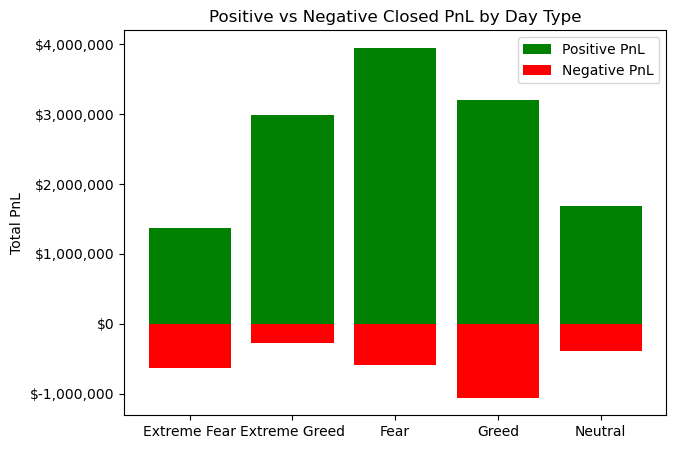

In [52]:
x = summary['classification']
plt.figure(figsize=(7,5))

plt.bar(x, summary['Positive'], color='green', label='Positive PnL')
plt.bar(x, summary['Negative'], color='red', label='Negative PnL')   

plt.ylabel('Total PnL')
plt.title('Positive vs Negative Closed PnL by Day Type')
plt.legend()
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.show()

### Positive vs Negative Closed PnL by Market Sentiment

**Insight:**  
Greed and Extreme Greed days generate higher total positive PnL,
while Fear regimes exhibit larger negative PnL, indicating increased
downside risk during periods of market uncertainty.

**Graph-2**

In [53]:
win_rate= (df_final.groupby('classification').agg(
        
        Total_Trades=('Closed PnL', 'count')).reset_index())
    

In [54]:
win_rate.head()

,classification,Total_Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


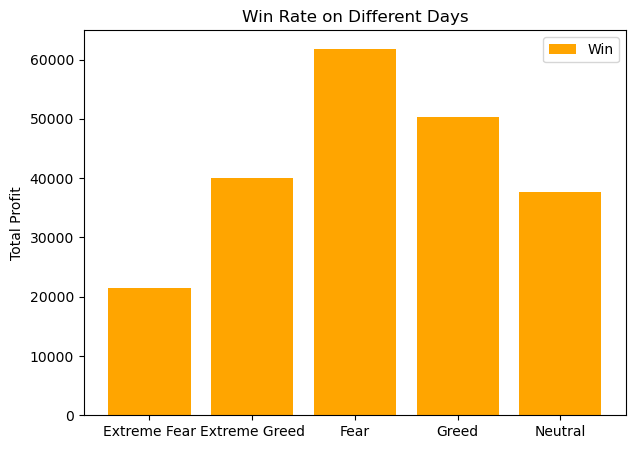

In [55]:
x = win_rate['classification']
plt.figure(figsize=(7,5))

plt.bar(x, win_rate['Total_Trades'], color='orange', label='Win')


plt.ylabel('Total Profit')
plt.title('Win Rate on Different Days')
plt.legend()

plt.show()

### Win Rate Across Market Sentiment

**Insight:**  
Win rates are highest during Fear days, while Extreme Fear shows the
lowest win rate, suggesting that selective trading during Fear
conditions can be more effective than during extreme panic.

**Graph-3**

In [56]:
draw_down= (df_final.groupby('classification').agg(Net_Drawdown=('Closed PnL', 'sum')).reset_index())

In [57]:
draw_down.head()

,classification,Net_Drawdown
0,Extreme Fear,7.391102e+05
1,Extreme Greed,2.715171e+06
2,Fear,3.357155e+06
3,Greed,2.150129e+06
4,Neutral,1.292921e+06


In [58]:
draw_down['Net_Drawdown($)']= draw_down['Net_Drawdown'].round(2)

In [59]:
draw_down.drop(columns=['Net_Drawdown'], axis=1,inplace= True)

In [60]:
draw_down.head()

,classification,Net_Drawdown($)
0,Extreme Fear,739110.25
1,Extreme Greed,2715171.31
2,Fear,3357155.44
3,Greed,2150129.27
4,Neutral,1292920.68


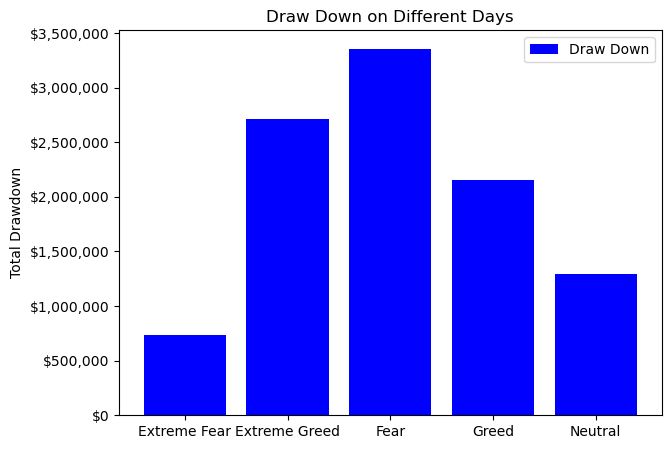

In [61]:
x = draw_down['classification']
plt.figure(figsize=(7,5))

plt.bar(x, draw_down['Net_Drawdown($)'], color='blue', label='Draw Down')


plt.ylabel('Total Drawdown')
plt.title('Draw Down on Different Days')
plt.legend()
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.show()

### Drawdown Across Market Sentiment

**Insight:**  
Fear days exhibit the highest drawdowns, indicating increased downside
risk and capital stress, while Neutral and Extreme Fear days show
relatively lower drawdowns.


**Graph-3**

In [62]:
total_trade= (df_final.groupby('classification').agg(Net_Trade=('Account', 'count')).reset_index())

In [63]:
total_trade.head()

,classification,Net_Trade
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


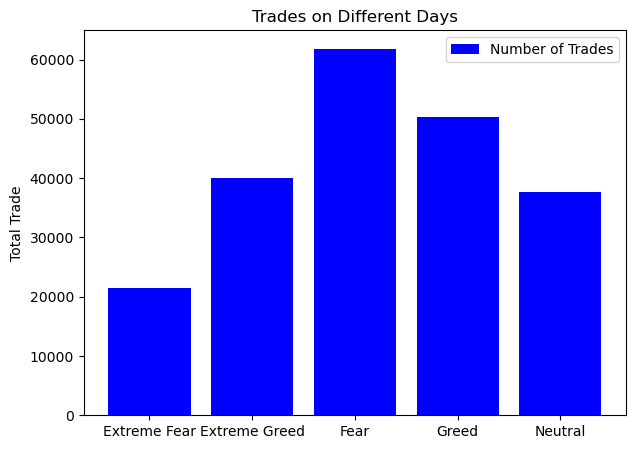

In [64]:
x = total_trade['classification']
plt.figure(figsize=(7,5))

plt.bar(x, total_trade['Net_Trade'], color='blue', label='Number of Trades')


plt.ylabel('Total Trade')
plt.title('Trades on Different Days')
plt.legend()


plt.show()

### Trade Activity Across Market Sentiment

**Insight:**  
Trade activity peaks during Fear and Greed days, suggesting heightened
market participation during emotionally charged market conditions.


**Graph-4**

In [65]:
User_Trade= (df_final.groupby('Account').agg(Net_User_Trade=('Account', 'count')).reset_index())

In [69]:
User_Trade.shape

(32, 2)

In [ ]:
User_Trade['Net_User_Trade'].mean()

6600.5625

In [ ]:
User_Trade['Freq_NotFreq']= np.where(User_Trade['Net_User_Trade'] >6600 , 'Frequent', 'Not_Frequent')

In [ ]:
User_Trade.head()

,Account,Net_User_Trade,Freq_NotFreq
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Not_Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Not_Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Not_Frequent


In [ ]:
total_trade['Trade_Percent'] = (
    total_trade['Net_Trade'] / total_trade['Net_Trade'].sum()
) * 100

In [ ]:
total_trade.head()

,classification,Net_Trade,Trade_Percent
0,Extreme Fear,21400,10.131712
1,Extreme Greed,39992,18.933992
2,Fear,61837,29.276387
3,Greed,50303,23.815679
4,Neutral,37686,17.842229


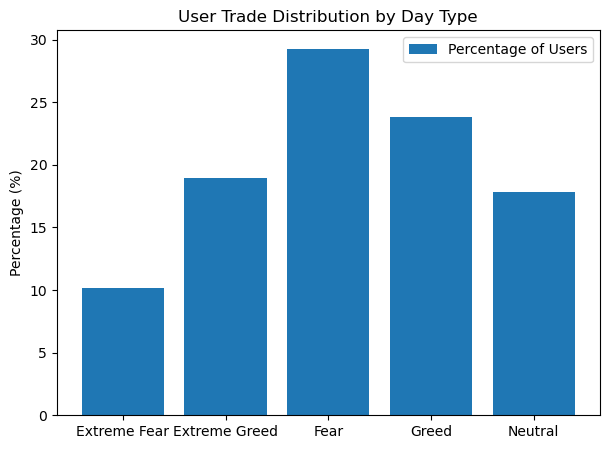

In [ ]:
x = total_trade['classification']

plt.figure(figsize=(7,5))
plt.bar(x, total_trade['Trade_Percent'], label='Percentage of Users')

plt.ylabel('Percentage (%)')
plt.title('User Trade Distribution by Day Type')
plt.legend()
plt.show()

### User Participation Across Market Sentiment

**Insight:**  
A higher proportion of users trade during Fear and Greed days, while
Extreme Fear sees reduced participation, reflecting cautious behavior
during periods of extreme uncertainty.


**Graph-5**

In [ ]:
total_notfreq= User_Trade['Freq_NotFreq'].value_counts()['Not_Frequent']

In [ ]:
total_notfreq

21

In [ ]:
total_freq= 11

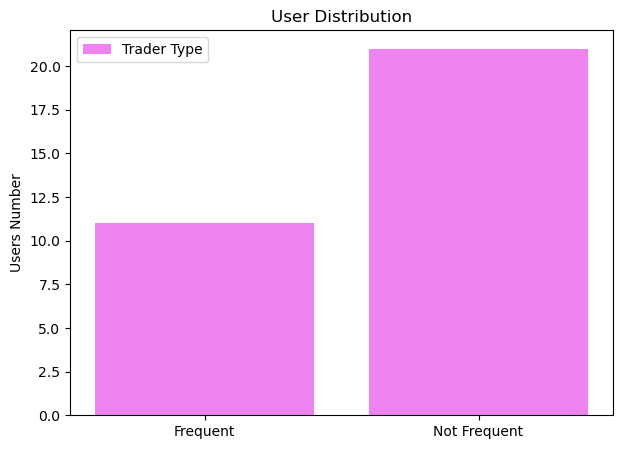

In [ ]:
categories = ['Frequent', 'Not Frequent']
counts = [11, 21]

plt.figure(figsize=(7,5))
plt.bar(categories, counts, color= 'violet',label= 'Trader Type')

plt.ylabel('Users Number')
plt.title('User Distribution')
plt.legend()
plt.show()

### Active vs Inactive Users

**Insight:**  
The number of inactive users (21) is nearly double the number of active
users (11), indicating that a majority of users trade infrequently.



## Strategy Ideas / Rules of Thumb

1. **Play it Safe on Fear Days**  
   When the market is in a Fear phase, it’s better to cut down on leverage
   and avoid overtrading. The data shows higher risk and lower consistency
   during these periods, so focusing on fewer, well-planned trades helps
   limit losses.

2. **Push Slightly During Greed**  
   On Greed days, performance improves overall, so traders with a decent
   track record can afford to trade a bit more actively. That said, risk
   controls like stop-losses are still important to prevent sudden reversals
   from wiping out gains.


## Summary

### Methodology
Trader data from Hyperliquid was combined with daily Bitcoin market
sentiment (Fear/Greed). All trades were aggregated at a daily level and
matched with the corresponding sentiment. Metrics such as Closed PnL,
win rate, drawdown proxy, leverage, trade frequency, and long/short
ratios were calculated. Traders were also grouped based on activity
levels and leverage to compare behavior across sentiment regimes.

### Key Insights
- Performance is generally better on Greed days, with higher positive
  PnL and win rates, while Fear days show larger drawdowns.
- Trading behavior changes with sentiment, as both leverage and trading
  activity increase during Fear and Greed periods.
- Traders using higher leverage or trading more frequently experience
  larger gains in Greed phases but suffer more during Fear phases.

### Strategy Recommendations
- On Fear days, lowering leverage and reducing trade frequency helps
  control losses.
- During Greed days, slightly higher activity can be justified for
  consistent traders, as long as risk limits are kept in place.
